  ✅ 检测到 Notebook 环境 → 后端已切换为 inline
  📋 停用词已加载: 15 个
     前10个: ['都是', '所有', '也是', '还有', '只有', '就是', '正是', '时', '有', '不是'] ...
  PCA 文体分析 v4.3 — 配置概览
  分析模式     : common_nouns  →  仅保留一般名词（n），剔除专名、代名词与数词名词
  特征选择策略 : 累计相对频率百分比控制
  累计频率阈值  : ['50%', '60%', '70%', '80%', '85%', '90%', '95%']
  主分析阈值    : 85%
  停用词       : 启用 (15 个)
  <OTHER>合并  : 启用（阈值=3）
  PCA中保留<OTHER>: 否（仅用于相对频率计算）
  语料根目录    : C:\temp\zhuowen
  作者列表      : ['2', '5', '9']
  每位作者      : 11 篇
  平行分析      : 1000 次 (seed=42)
  运行环境      : Notebook (inline)
  输出目录      : C:\temp\zhuowen\PCA_Result

【阶段 1】语料读取与分词处理  (一般名词（n）)
  ✅ [2]: 11 个文件
  ✅ [5]: 11 个文件
  ✅ [9]: 11 个文件

✅ 成功处理 33 篇文本
  📋 停用词共剔除约 19 次（各文档合计）

【阶段 2】TF 矩阵构建 → <OTHER> 合并 → 相对频率
  原始词表       : 860 词
  总词例数(Token) : 2462

  📦 <OTHER> 合并:
     低频词数     : 666 词（全局频次 < 3）
     合并为 <OTHER>: 总计 812 次 (24.80%)
     保留高频词   : 194 词

  ✅ 相对频率验证: 每行之和 = 1.0（最大偏差 2.22e-16）

--- 累计相对频率特征选择统计（含 <OTHER>）---
    阈值     词数      累计覆盖率     新增词数 含<OTHER>
─────────────────────

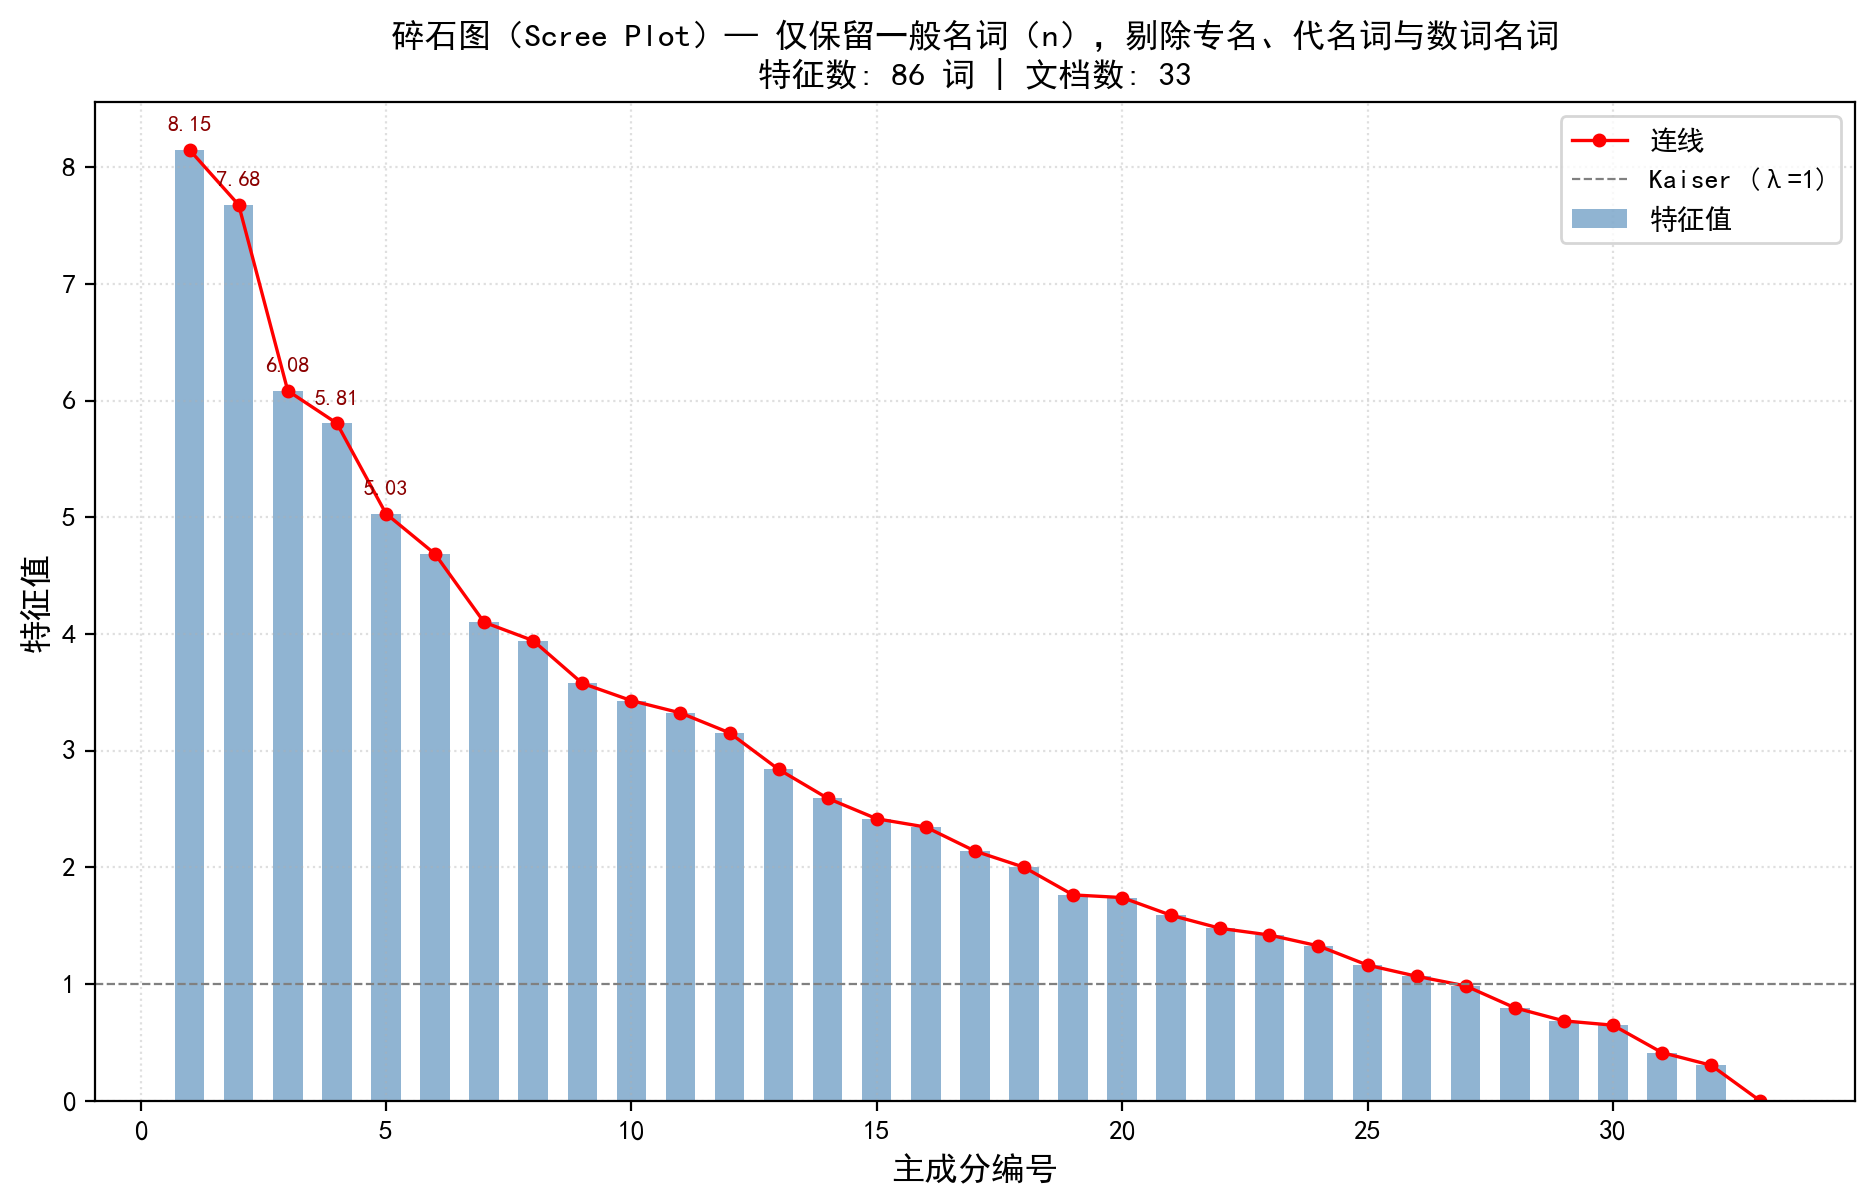


📊 Parallel_Analysis_common_nouns.png


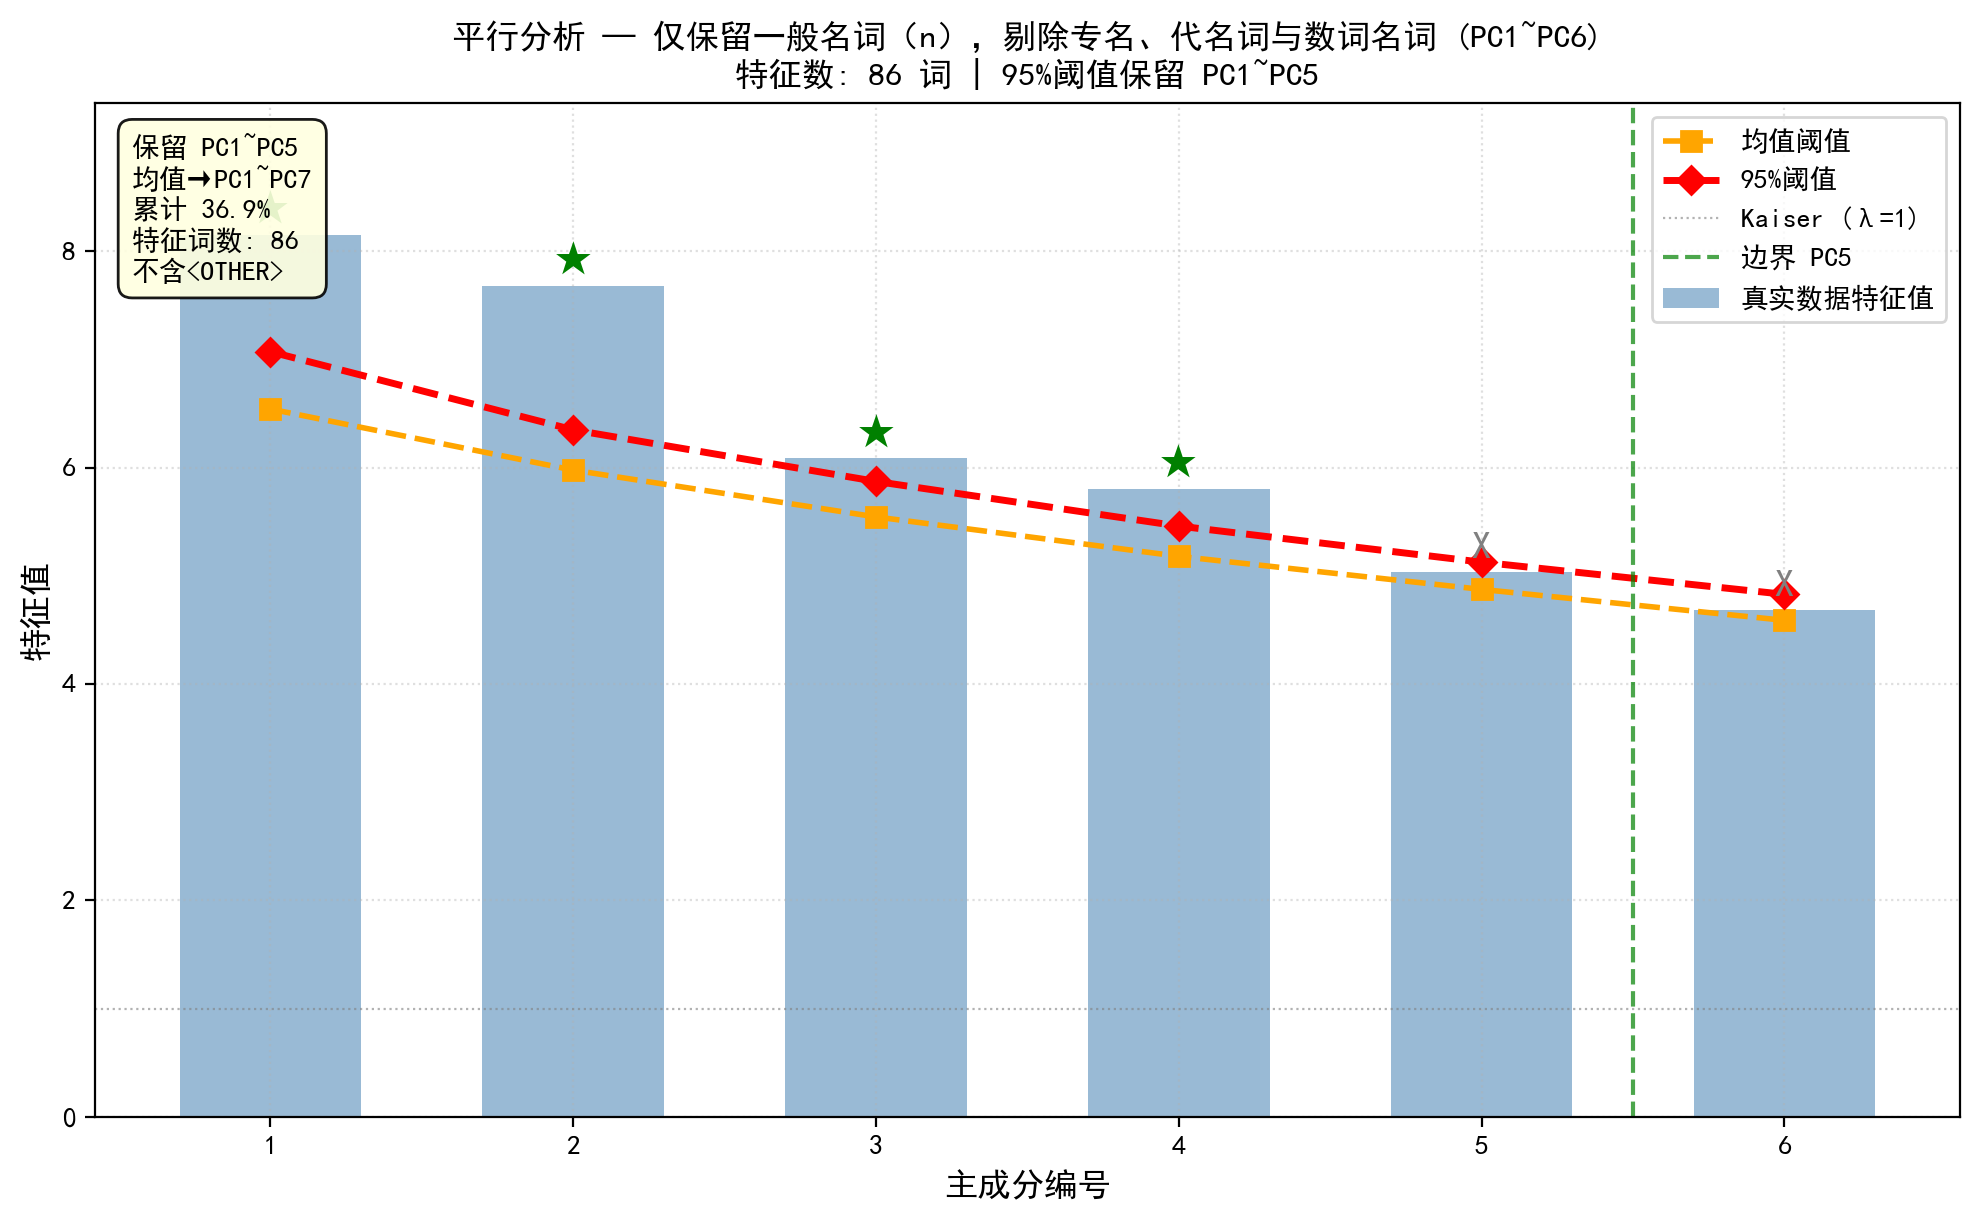


📊 Sensitivity_Analysis_common_nouns.png


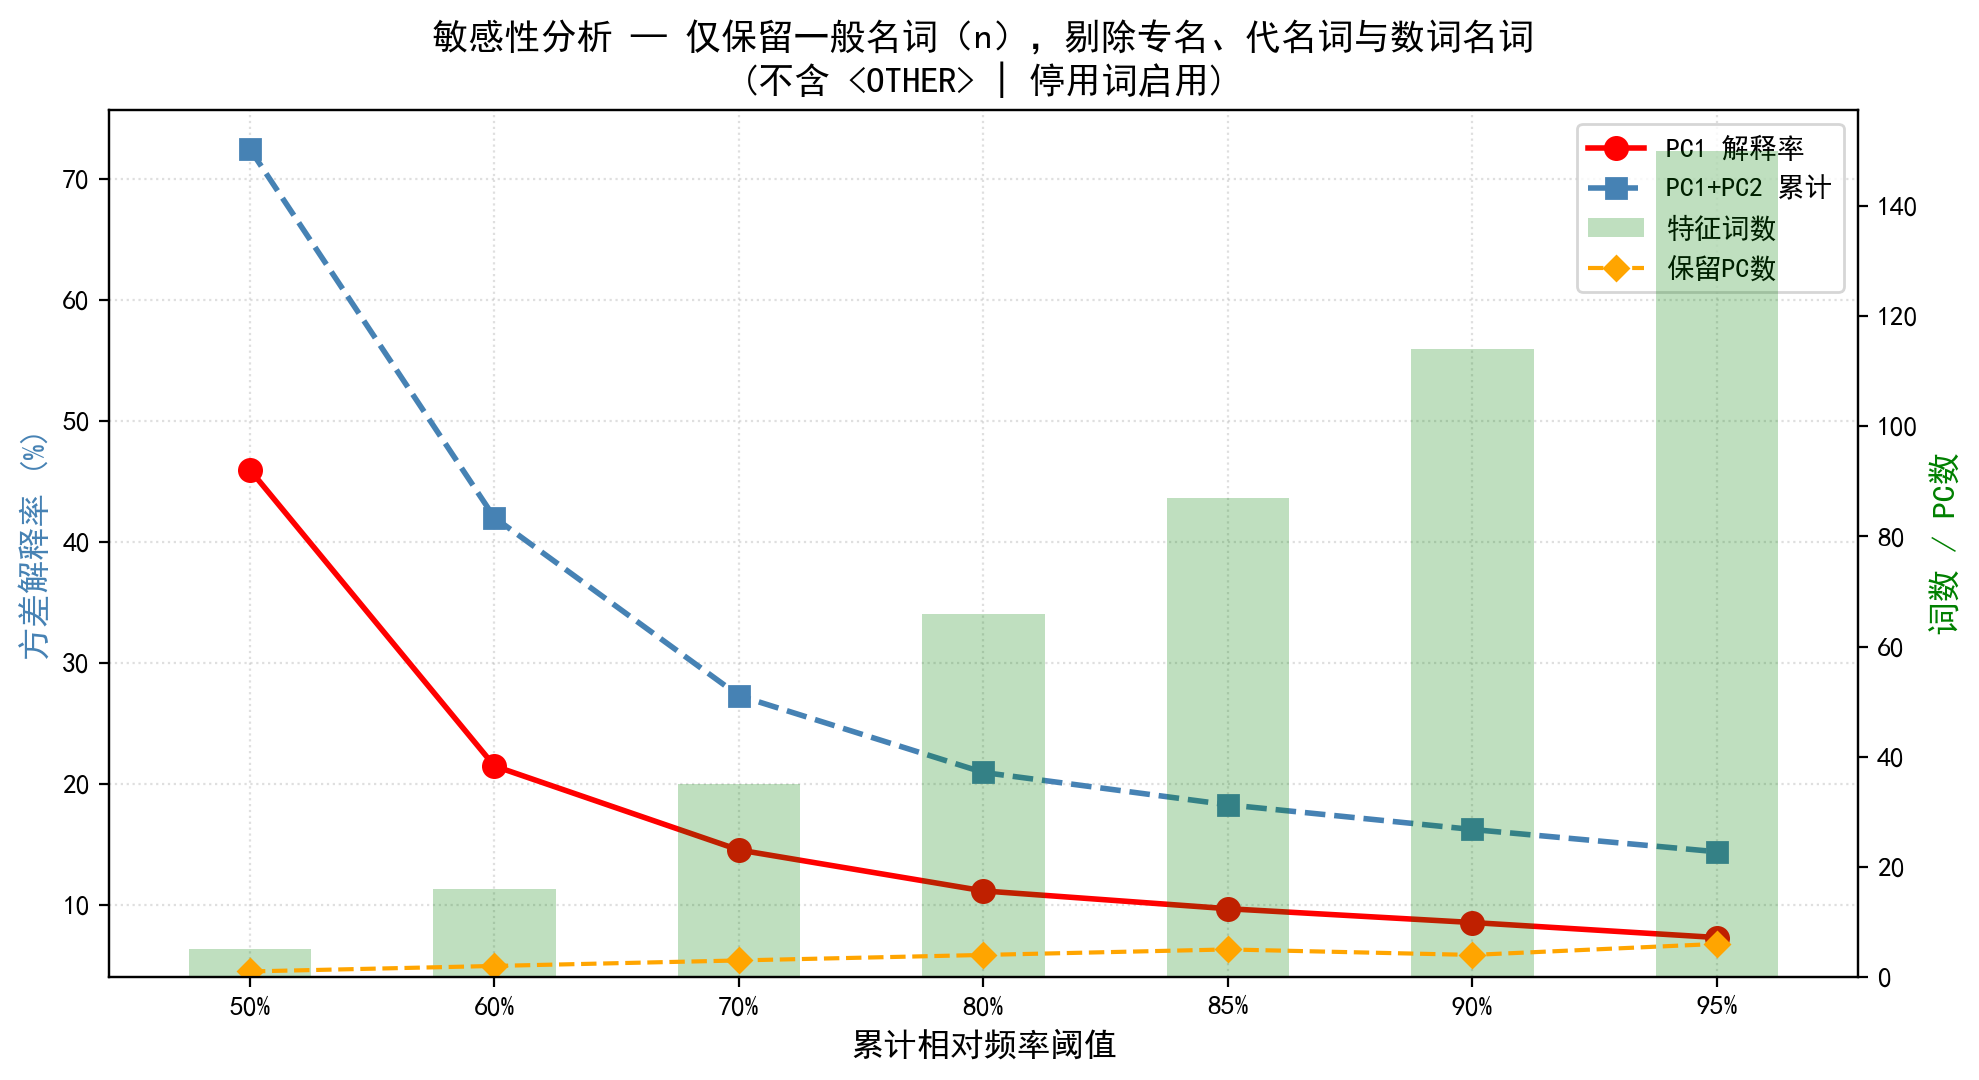


📊 PC_loading_common_nouns.png


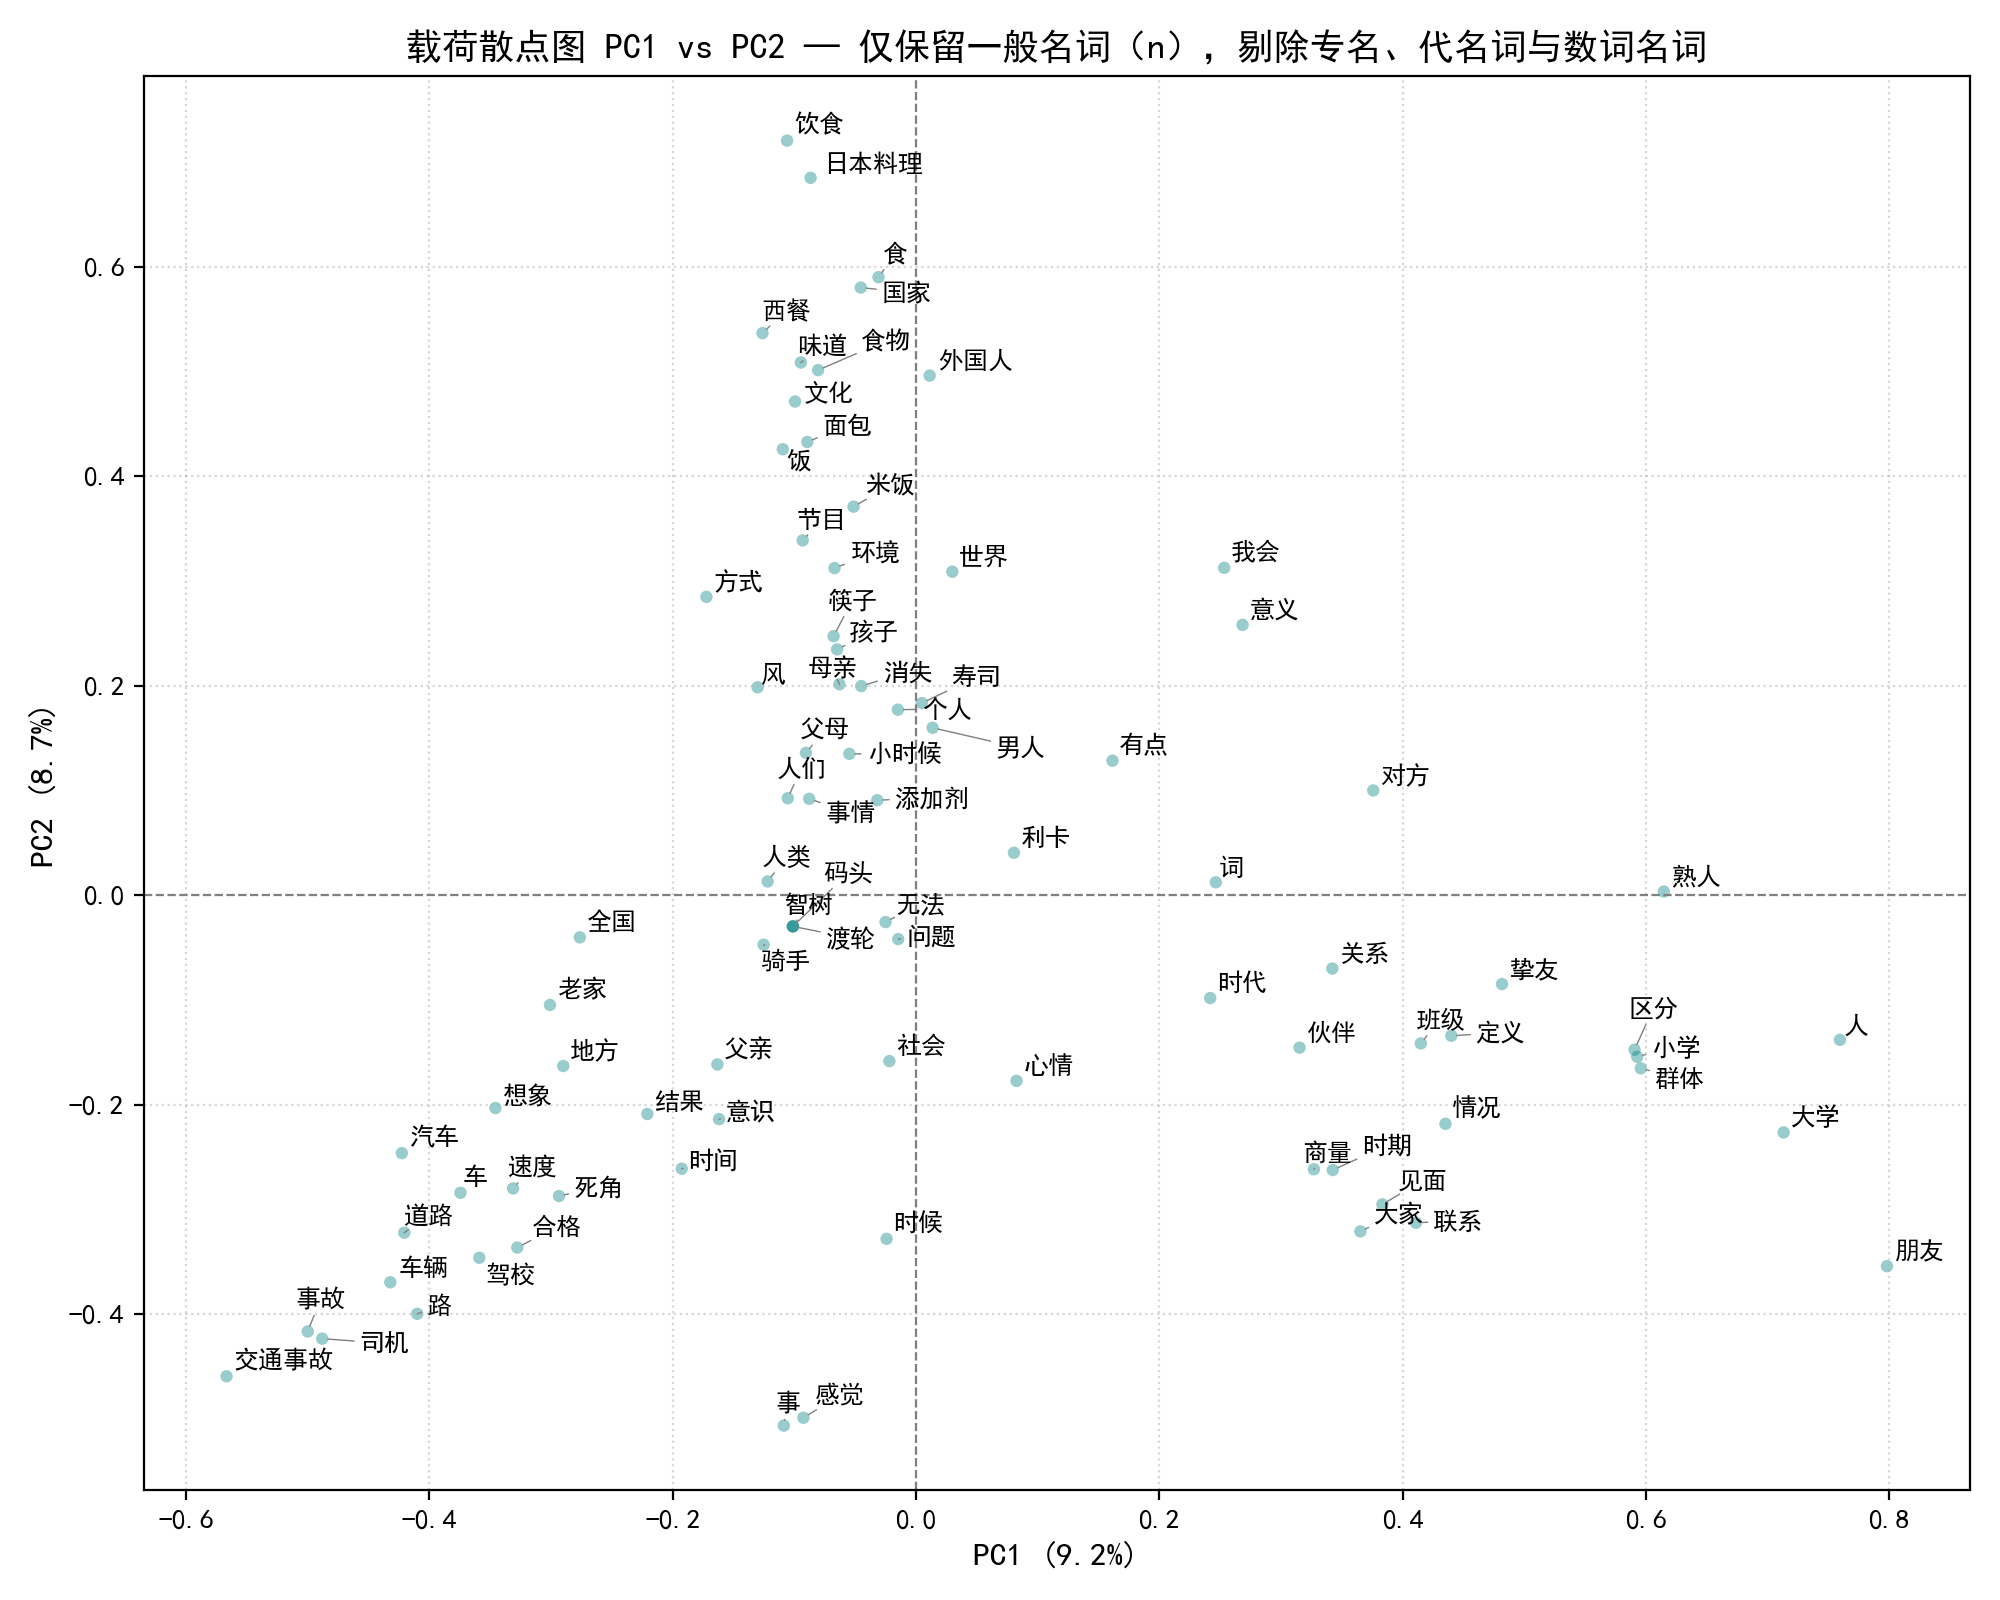


📊 PC_score_common_nouns.png


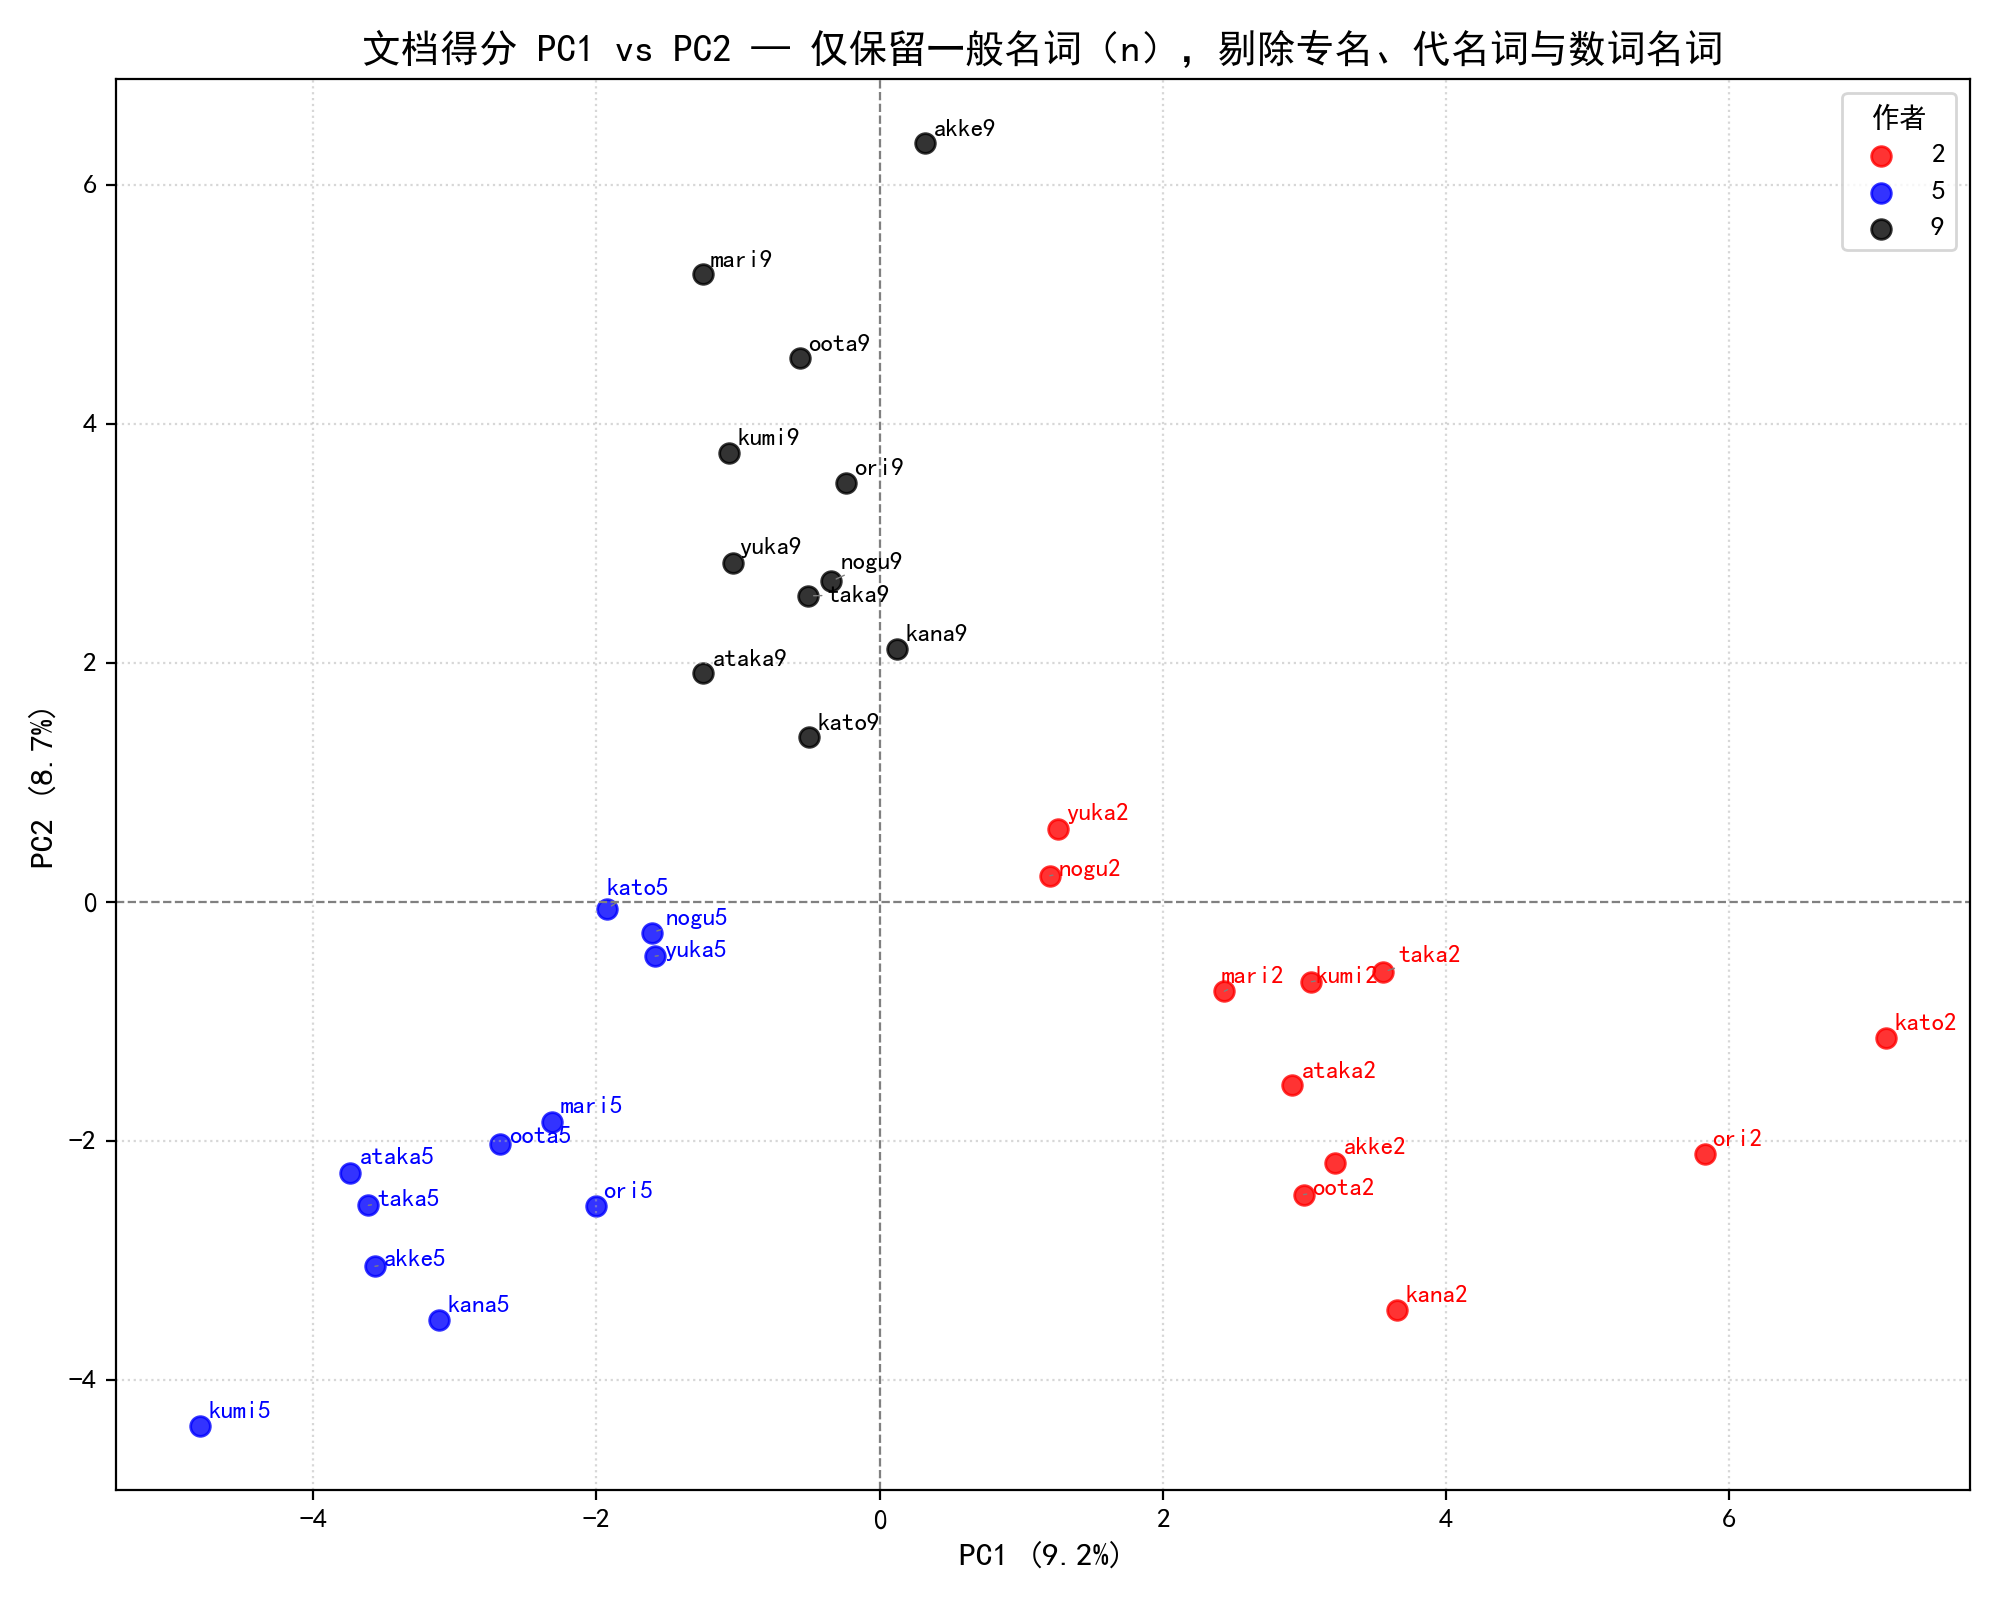


📊 Eigenvalue_Table_common_nouns.png


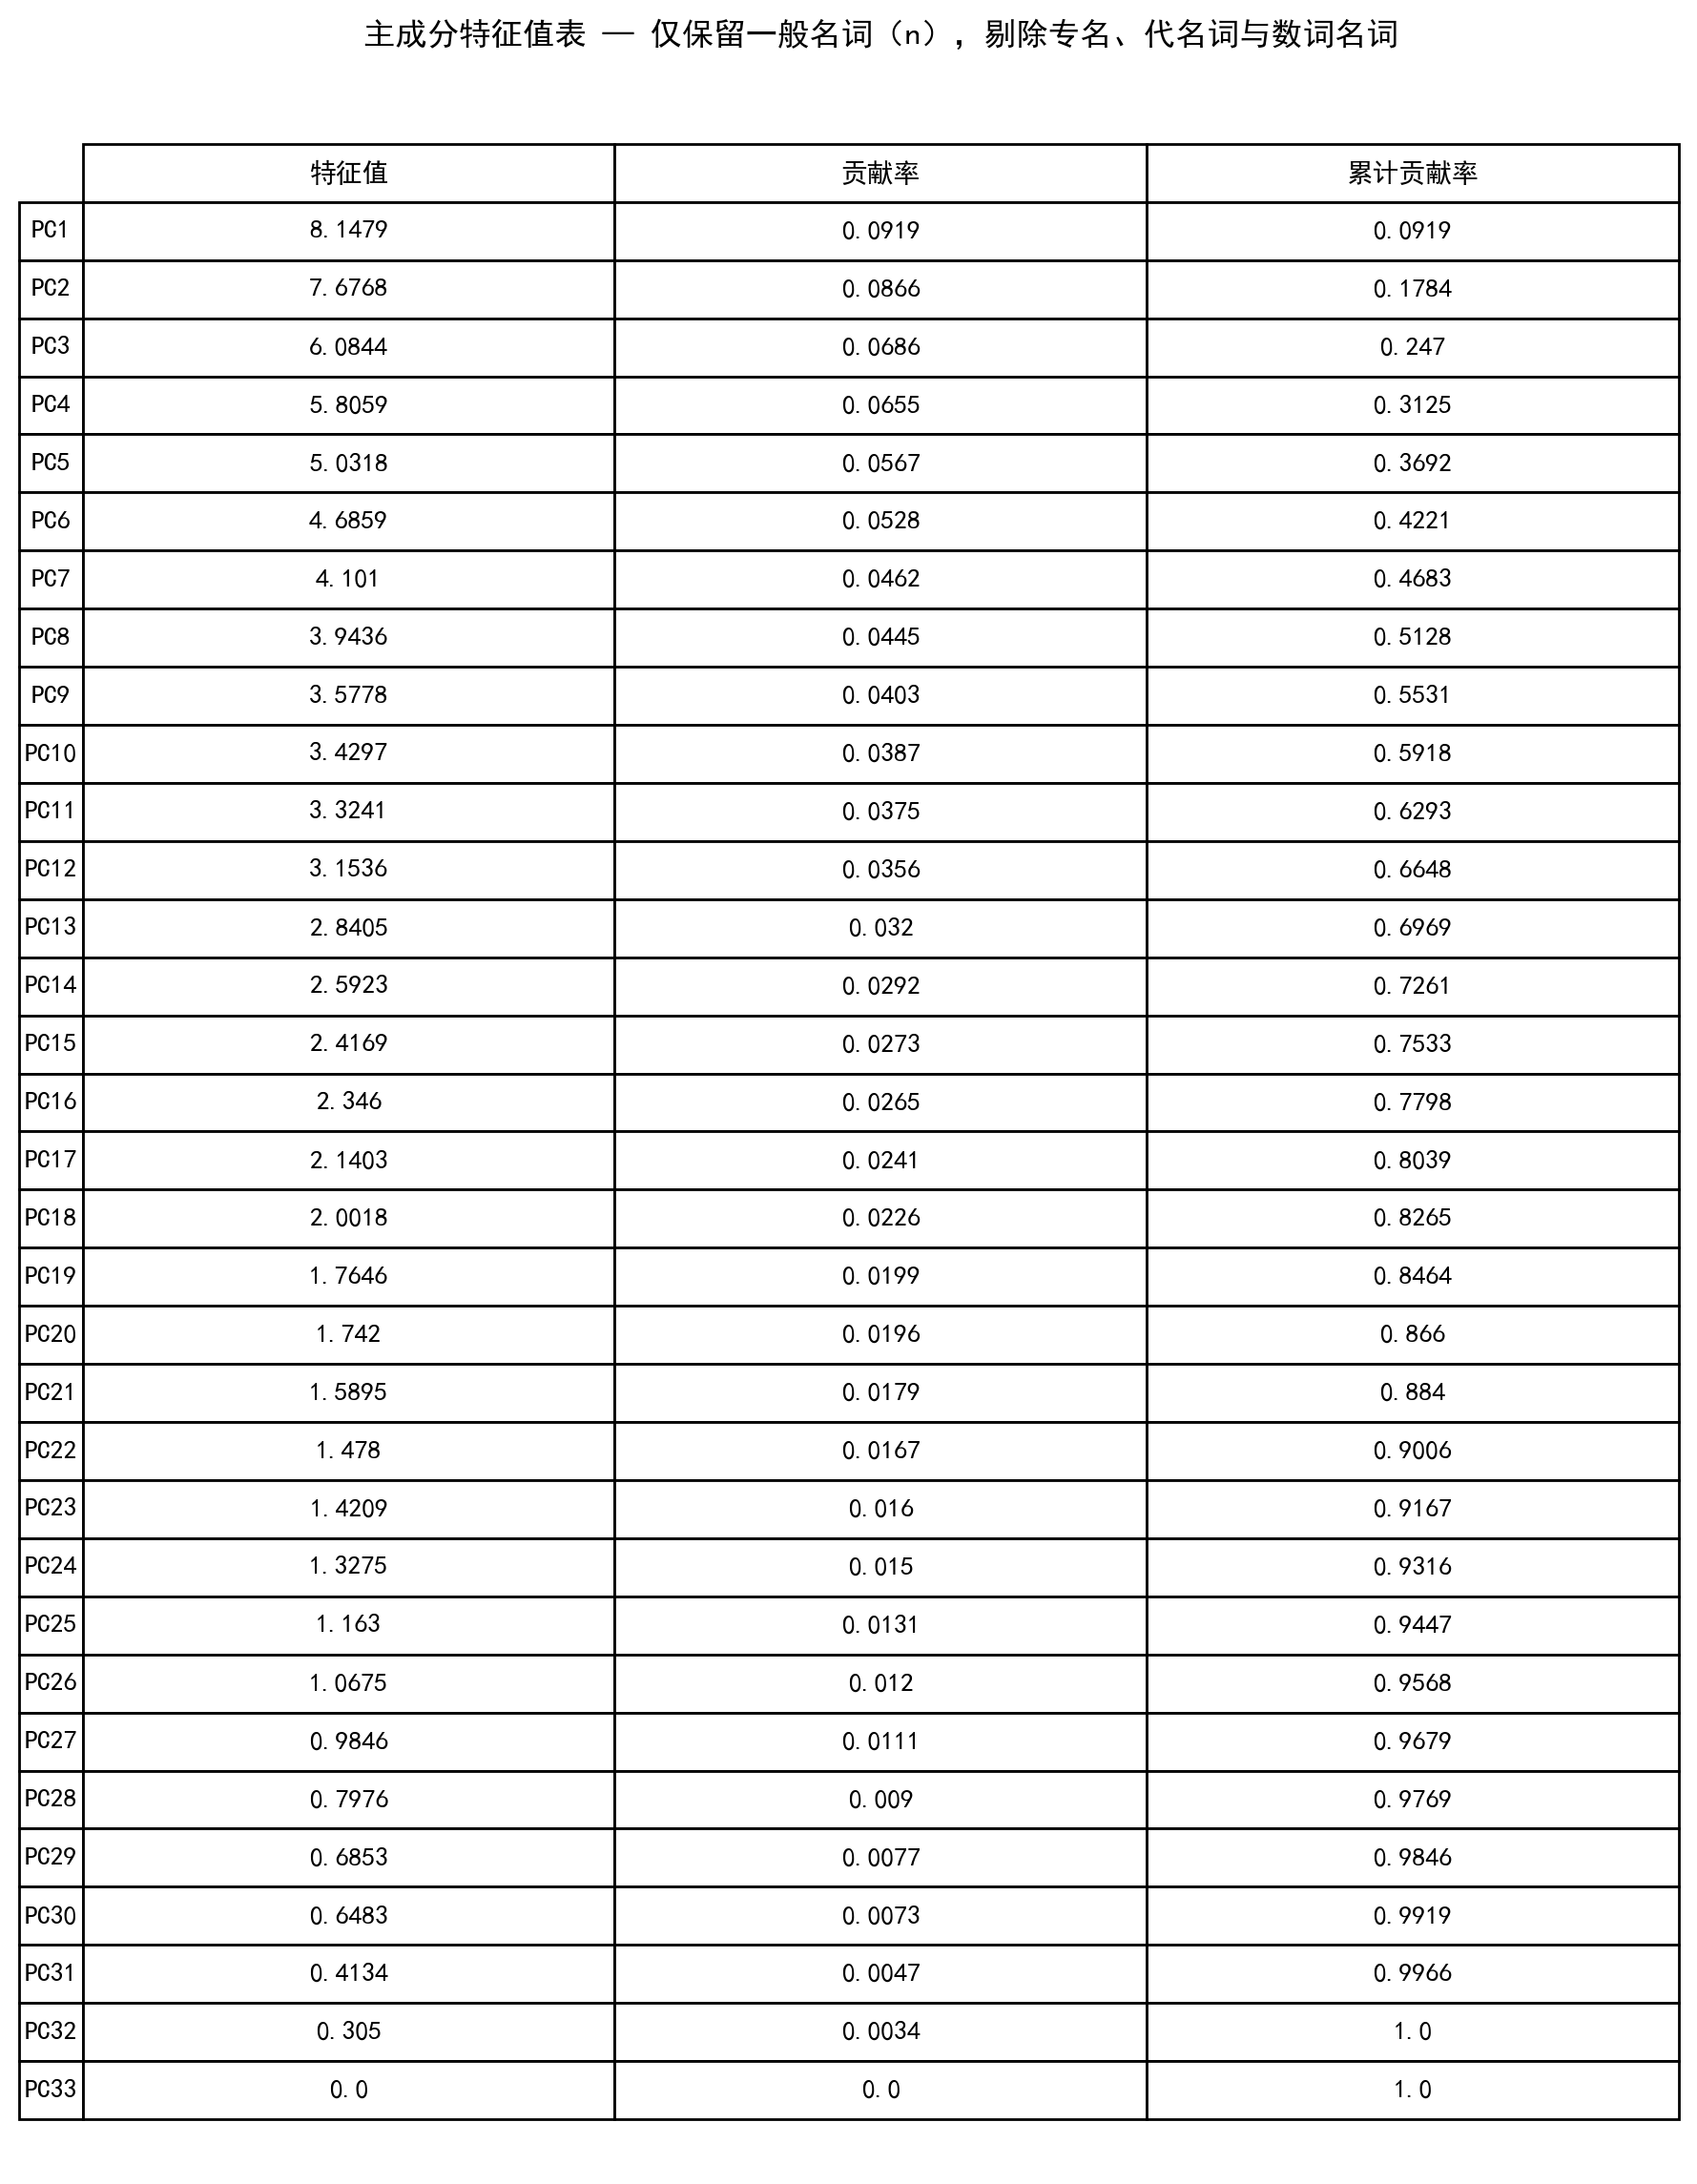


全部计算结束！


In [6]:
"""
================================================================================
作者文体风格 PCA 分析脚本（配置驱动版 v4.3 稳定修正版）
================================================================================
版本说明：
  v4.0  基础版（百分比控制 / STOP_WORDS / <OTHER> 合并）
  v4.1  修复 Notebook 弹窗 + 末尾统一显示
  v4.2  common_nouns 模式 + 图片顺序基于 tag
  v4.3  ★ <OTHER> 策略显式化（用户指定） + common_nouns 白名单 bug 修复

  ★ 所有需要用户调整的选项均集中在下方「配置区」内 ★
================================================================================
"""

from pathlib import Path

# ==============================================================================
# A. 语料与路径配置
# ==============================================================================
CORPUS_ROOT   = Path(r"C:\temp\zhuowen")
AUTHORS       = ["2", "5", "9"]
EXPECTED_PER_AUTHOR = 11
OUTPUT_SUBDIR = "PCA_Result"

# ==============================================================================
# B. ★ 分析模式选择（核心开关，四选一）
# ==============================================================================
# "function_words" → 功能词（虚词）分析
# "content_words"  → 内容词（实词）分析
# "common_nouns"   → ★ 仅一般名词（n）
# "all_words"      → 全词分析
# ==============================================================================
ANALYSIS_MODE = "common_nouns"

# ==============================================================================
# C. 词性过滤规则
# ==============================================================================
REMOVE_FUNCTION_MODE = {
    'n', 'ng', 'nr', 'nrfg', 'nrt', 'ns', 'nt', 'nz',
    'v', 'vg', 'vn', 'vq', 'vd', 'vi', 'vl',
    'a', 'ad', 'ag', 'an',
    'm', 'q', 'mq', 't', 's', 'f',
}
REMOVE_CONTENT_MODE = {
    'd', 'df', 'dg', 'c', 'p',
    'u', 'ug', 'uj', 'ul', 'uv', 'uz',
    'r', 'rg', 'rr', 'rz', 'e', 'y', 'h', 'k','x',
}
PREFIX_REMOVE_RULES = [
    ('n', {"function_words"}), ('v', {"function_words"}), ('a', {"function_words"}),
    ('m', {"function_words"}), ('q', {"function_words"}),
    ('d', {"content_words"}), ('c', {"content_words"}), ('p', {"content_words"}),
    ('u', {"content_words"}), ('r', {"content_words"}),
]

# ==============================================================================
# C+. 自定义停用词表
# ==============================================================================
STOP_WORDS = [
    "是", "不是", "都是", "也是", "就是", "正是", "乃是",
    "有", "没有", "还有", "只有", "所有", "上", "时",
    "在",
]
USE_STOP_WORDS = True

# ==============================================================================
# D. ★ 低频词（<OTHER>）处理策略（v4.3 显式化）
# ==============================================================================
# ① 是否启用 <OTHER> 合并
USE_OTHER_MERGE = True
#USE_OTHER_MERGE = False

# ② 合并阈值（仅 USE_OTHER_MERGE=True 时生效）
OTHER_MIN_FREQ = 3
# ③ PCA 中是否保留 <OTHER>
#KEEP_OTHER_IN_PCA = True
KEEP_OTHER_IN_PCA = False

# ==============================================================================
# E. 特征筛选配置
# ==============================================================================
CUM_FREQ_THRESHOLDS = [0.50, 0.60, 0.70, 0.80, 0.85, 0.90, 0.95]
PRIMARY_THRESHOLD = 0.85

# ==============================================================================
# F. PCA 与平行分析配置
# ==============================================================================
N_SIMULATIONS = 1000
RANDOM_SEED   = 42
N_PLOT_COMPONENTS = 7

# ==============================================================================
# G. 可视化配置
# ==============================================================================
SHOW_TOP_N_WORDS_IN_LOADING = 100
SHOW_PLOTS_IN_NOTEBOOK = True
PLOT_DPI        = 200
SCATTER_ALPHA   = 0.4
SCORE_ALPHA     = 0.8


AUTHOR_COLORS = {
    "2":       "red",
    "5": "blue",
    "8":      "green",
}

# ==============================================================================
# H. 字体配置
# ==============================================================================
FONT_SANS_SERIF = ['SimHei', 'Microsoft YaHei', 'Arial']

# ==============================================================================
#                          【配 置 区 结 束】
# ==============================================================================

"""
================================================================================
                       以下为程序主体（一般无需修改）
================================================================================
"""

import os
import re
import warnings
warnings.filterwarnings("ignore")

# ==============================================================================
# Notebook 后端设置
# ==============================================================================
def _setup_notebook_backend():
    if os.environ.get("PCA_NOTEBOOK") == "1":
        import matplotlib
        try:
            matplotlib.use('module://matplotlib_inline.backend_inline')
            print("  ✅ [env] Notebook 环境 → 后端已切换为 inline")
            return 'inline'
        except Exception as e:
            print(f"  ⚠️ inline 后端不可用: {e}，降级为 Agg")
            matplotlib.use('Agg')
            return 'inline_fallback'

    try:
        ip = get_ipython()
        if ip is not None:
            import matplotlib
            try:
                ip.run_line_magic('matplotlib', 'inline')
                print("  ✅ 检测到 Notebook 环境 → 后端已切换为 inline")
                return 'inline'
            except Exception:
                try:
                    matplotlib.use('module://matplotlib_inline.backend_inline')
                    print("  ✅ 检测到 Notebook 环境 → 后端已切换为 inline")
                    return 'inline'
                except Exception:
                    matplotlib.use('Agg')
                    print("  ℹ️ 强制使用静默模式（末尾内嵌显示）")
                    return 'agg_notebook'
    except NameError:
        pass

    import matplotlib
    if SHOW_PLOTS_IN_NOTEBOOK:
        try:
            matplotlib.use('TkAgg')
            print("  ℹ️ 脚本环境 → TkAgg 后端")
            return 'tkagg'
        except Exception:
            matplotlib.use('Agg')
            return 'agg'
    else:
        matplotlib.use('Agg')
        return 'agg'

_BACKEND = _setup_notebook_backend()

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

plt.rcParams['font.sans-serif'] = FONT_SANS_SERIF
plt.rcParams['axes.unicode_minus'] = False

from matplotlib.font_manager import fontManager
_available_fonts = {f.name for f in fontManager.ttflist}
_configured = plt.rcParams['font.sans-serif']
if not any(f in _available_fonts for f in _configured):
    for fallback in ['Noto Sans CJK SC', 'WenQuanYi Micro Hei', 'DejaVu Sans']:
        if fallback in _available_fonts:
            plt.rcParams['font.sans-serif'] = [fallback]
            print(f"  ⚠️ 字体不可用，已切换为: {fallback}")
            break

try:
    from adjustText import adjust_text
    HAS_ADJUST_TEXT = True
except ImportError:
    HAS_ADJUST_TEXT = False

import jieba
import jieba.posseg as pseg

# ==============================================================================
# 分析模式策略（★ v4.3 修正：common_nouns 不再设 remove_pos_set）
# ==============================================================================
MODE_DESCRIPTIONS = {
    "function_words": "功能词分析（剔除实词，保留虚词）",
    "content_words":  "内容词分析（剔除虚词，保留实词）",
    "common_nouns":   "仅保留一般名词（n），剔除专名、代名词与数词名词",
    "all_words":      "全词分析（不做词性过滤）",
}

if ANALYSIS_MODE not in MODE_DESCRIPTIONS:
    raise ValueError(f"无效 ANALYSIS_MODE: '{ANALYSIS_MODE}'")

if ANALYSIS_MODE == "function_words":
    remove_pos_set = REMOVE_FUNCTION_MODE
    token_label    = "功能词（虚词）"
elif ANALYSIS_MODE == "content_words":
    remove_pos_set = REMOVE_CONTENT_MODE
    token_label    = "内容词（实词）"
elif ANALYSIS_MODE == "common_nouns":
    remove_pos_set = None   # ★ 白名单模式，不用黑名单
    token_label    = "一般名词（n）"
else:
    remove_pos_set = set()
    token_label    = "全部词（未过滤）"

# 停用词
stop_words_set = set(STOP_WORDS) if USE_STOP_WORDS else set()
if USE_STOP_WORDS and len(stop_words_set) > 0:
    print(f"  📋 停用词已加载: {len(stop_words_set)} 个")
    if len(stop_words_set) <= 10:
        print(f"     {list(stop_words_set)}")
    else:
        print(f"     前10个: {list(stop_words_set)[:10]} ...")
else:
    print("  ℹ️ 停用词未启用")

OUTPUT_DIR = CORPUS_ROOT / OUTPUT_SUBDIR
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 打印配置概览
print("=" * 70)
print("  PCA 文体分析 v4.3 — 配置概览")
print("=" * 70)
print(f"  分析模式     : {ANALYSIS_MODE}  →  {MODE_DESCRIPTIONS[ANALYSIS_MODE]}")
print(f"  特征选择策略 : 累计相对频率百分比控制")
print(f"  累计频率阈值  : {[f'{t*100:.0f}%' for t in CUM_FREQ_THRESHOLDS]}")
print(f"  主分析阈值    : {PRIMARY_THRESHOLD*100:.0f}%")
print(f"  停用词       : {'启用 (' + str(len(stop_words_set)) + ' 个)' if USE_STOP_WORDS else '未启用'}")
print(f"  <OTHER>合并  : {'启用（阈值=' + str(OTHER_MIN_FREQ) + '）' if USE_OTHER_MERGE else '禁用（直接删除低频词）'}")
print(f"  PCA中保留<OTHER>: {'是' if KEEP_OTHER_IN_PCA else '否（仅用于相对频率计算）'}")
print(f"  语料根目录    : {CORPUS_ROOT}")
print(f"  作者列表      : {AUTHORS}")
print(f"  每位作者      : {EXPECTED_PER_AUTHOR} 篇")
print(f"  平行分析      : {N_SIMULATIONS} 次 (seed={RANDOM_SEED})")
print(f"  运行环境      : {'Notebook (inline)' if _BACKEND.startswith('inline') else 'Script (' + _BACKEND + ')'}")
print(f"  输出目录      : {OUTPUT_DIR}")
print("=" * 70)
print()


# ==============================================================================
# 阶段 1：语料读取与分词处理
# ==============================================================================
print("=" * 70)
print(f"【阶段 1】语料读取与分词处理  ({token_label})")
print("=" * 70)

documents    = []
doc_labels   = []
author_labels = []

for author in AUTHORS:
    cleaned_dir = CORPUS_ROOT / author
    if not cleaned_dir.exists():
        raise FileNotFoundError(f"  ❌ 目录不存在: {cleaned_dir}")
    file_list = sorted(cleaned_dir.glob("*.txt"))
    if len(file_list) != EXPECTED_PER_AUTHOR:
        print(f"  ⚠️  [{author}]: {len(file_list)} 个文件（预期 {EXPECTED_PER_AUTHOR}）")
    else:
        print(f"  ✅ [{author}]: {len(file_list)} 个文件")

    for file_path in file_list:
        with open(file_path, "r", encoding="utf-8-sig", errors="ignore") as f:
            text = f.read()
        words = pseg.cut(text)
        filtered_tokens = []
        n_removed_stop = 0
        for word, flag in words:
            word = word.strip()
            if not word: continue
            if re.search(r"[\s\t\n\r ]", word): continue
            if re.search(r"[a-zA-Z0-9０-９]", word): continue
            if re.search(r"[^\u4e00-\u9fa5]", word): continue

            # ★ 停用词（最高优先级）
            if USE_STOP_WORDS and word in stop_words_set:
                n_removed_stop += 1
                continue

            # ★★★ v4.3 修正：common_nouns 白名单（独立、优先、不碰 remove_pos_set）★★★
            if ANALYSIS_MODE == "common_nouns":
                if flag == 'n':
                    filtered_tokens.append(word)
                continue

            if ANALYSIS_MODE == "all_words":
                filtered_tokens.append(word)
                continue

            # ★ 黑名单词性过滤（仅 function_words / content_words）
            if remove_pos_set is not None and flag in remove_pos_set:
                continue

            # ★ 前缀兜底规则
            skip = False
            for prefix, active_modes in PREFIX_REMOVE_RULES:
                if ANALYSIS_MODE in active_modes and flag.startswith(prefix):
                    skip = True
                    break
            if not skip:
                filtered_tokens.append(word)

        documents.append(filtered_tokens)
        doc_labels.append(file_path.stem)
        author_labels.append(author)

n_total_docs = len(documents)
assert n_total_docs == len(AUTHORS) * EXPECTED_PER_AUTHOR
print(f"\n✅ 成功处理 {n_total_docs} 篇文本")
if USE_STOP_WORDS and stop_words_set:
    print(f"  📋 停用词共剔除约 {n_removed_stop} 次（各文档合计）")
print()


# ==============================================================================
# 阶段 2：TF 矩阵构建 → <OTHER> 合并 → 相对频率
# ==============================================================================
print("=" * 70)
print("【阶段 2】TF 矩阵构建 → <OTHER> 合并 → 相对频率")
print("=" * 70)

all_words = sorted(list(set(w for doc in documents for w in doc)))
vocab_index = {w: i for i, w in enumerate(all_words)}
count_matrix = np.zeros((n_total_docs, len(all_words)), dtype=np.int64)
for doc_idx, doc in enumerate(documents):
    for word in doc:
        count_matrix[doc_idx, vocab_index[word]] += 1

df_counts_raw = pd.DataFrame(count_matrix, index=doc_labels, columns=all_words)
word_total_counts = df_counts_raw.sum(axis=0)

print(f"  原始词表       : {len(all_words)} 词")
print(f"  总词例数(Token) : {df_counts_raw.sum().sum():.0f}")

# ★★★ v4.3：<OTHER> 合并（受 USE_OTHER_MERGE 控制）★★★
if USE_OTHER_MERGE:
    low_freq_mask = word_total_counts < OTHER_MIN_FREQ
    n_low_freq = int(low_freq_mask.sum())

    if n_low_freq > 0:
        df_counts_main = df_counts_raw.loc[:, ~low_freq_mask].copy()
        df_counts_raw["<OTHER>"] = df_counts_raw.loc[:, low_freq_mask].sum(axis=1)
        other_total = df_counts_raw["<OTHER>"].sum()
        other_pct = other_total / df_counts_raw.sum().sum() * 100
        print(f"\n  📦 <OTHER> 合并:")
        print(f"     低频词数     : {n_low_freq} 词（全局频次 < {OTHER_MIN_FREQ}）")
        print(f"     合并为 <OTHER>: 总计 {other_total:.0f} 次 ({other_pct:.2f}%)")
        print(f"     保留高频词   : {len(df_counts_main.columns)} 词")
    else:
        df_counts_main = df_counts_raw.copy()
        print(f"\n  ℹ️ 无低频词需要合并（OTHER_MIN_FREQ={OTHER_MIN_FREQ}）")

    if "<OTHER>" not in df_counts_main.columns:
        if n_low_freq > 0:
            df_counts_main["<OTHER>"] = df_counts_raw["<OTHER>"]
        else:
            df_counts_main["<OTHER>"] = 0
else:
    # 不合并：直接删除低频词
    freq_mask = word_total_counts >= OTHER_MIN_FREQ
    df_counts_main = df_counts_raw.loc[:, freq_mask].copy()
    df_counts_main["<OTHER>"] = 0
    n_deleted = int((~freq_mask).sum())
    print(f"\n  ℹ️ <OTHER> 合并已禁用：直接删除 {n_deleted} 个低频词")

# ★ 在完整空间中计算相对频率（含 <OTHER>）
doc_totals_full = df_counts_main.sum(axis=1)
df_rel_freq_full = df_counts_main.div(doc_totals_full, axis=0).fillna(0)

# 验证 sum=1
row_sums = df_rel_freq_full.sum(axis=1)
max_dev = (row_sums - 1.0).abs().max()
print(f"\n  ✅ 相对频率验证: 每行之和 = 1.0（最大偏差 {max_dev:.2e}）")

# 全局相对频率（用于累计截断）
word_rel_freq = df_rel_freq_full.sum(axis=0) / df_rel_freq_full.sum().sum()
word_rel_freq_sorted = word_rel_freq.sort_values(ascending=False)

# 累计相对频率统计
print(f"\n--- 累计相对频率特征选择统计（含 <OTHER>）---")
print(f"{'阈值':>6} {'词数':>6} {'累计覆盖率':>10} {'新增词数':>8} {'含<OTHER>':>8}")
print(f"{'─'*50}")

cum_stats = []
selected_words_by_threshold = {}

for threshold in sorted(CUM_FREQ_THRESHOLDS):
    cum_freq = word_rel_freq_sorted.cumsum()
    mask = cum_freq >= threshold
    if mask.any():
        n_needed = int(mask.argmax()) + 1
    else:
        n_needed = len(word_rel_freq_sorted)
    selected_words = word_rel_freq_sorted.head(n_needed).index
    selected_words_by_threshold[threshold] = selected_words
    actual_cov = word_rel_freq_sorted.head(n_needed).sum()
    has_other = '<OTHER>' in selected_words
    prev = cum_stats[-1]['词数'] if cum_stats else 0
    cum_stats.append({
        '阈值': f'{threshold*100:.0f}%',
        '词数': n_needed,
        '累计覆盖率': round(actual_cov, 4),
        '新增词数': n_needed - prev,
        '含OTHER': '是' if has_other else '否',
    })
    other_mark = " ★" if has_other else ""
    print(f"  {threshold*100:>4.0f}%   {n_needed:>6}   {actual_cov:>10.2%}   "
          f"{n_needed - prev:>8}   {'是' if has_other else '否':>8}{other_mark}")

df_cum_stats = pd.DataFrame([
    {'阈值': s['阈值'], '词数': s['词数'], '累计覆盖率': s['累计覆盖率'],
     '新增词数': s['新增词数'], '含OTHER': s['含OTHER']}
    for s in cum_stats
])
print()
print("--- TF 变量个数统计表 ---")
print(df_cum_stats.to_string(index=False))

# 确定主分析词集
if PRIMARY_THRESHOLD not in CUM_FREQ_THRESHOLDS:
    raise ValueError(f"PRIMARY_THRESHOLD={PRIMARY_THRESHOLD} 不在 CUM_FREQ_THRESHOLDS 中。")
primary_words = selected_words_by_threshold[PRIMARY_THRESHOLD]
n_features = len(primary_words)
has_other_main = '<OTHER>' in primary_words
print(f"\n📌 主分析采用: 累计 {PRIMARY_THRESHOLD*100:.0f}% → {n_features} 个变量"
      f"{'（含 <OTHER>）' if has_other_main else ''}")

# 构建主分析矩阵
df_rel_freq = df_rel_freq_full[primary_words].copy()

# ★★★ v4.3：PCA 中是否保留 <OTHER>（受 KEEP_OTHER_IN_PCA 控制）★★★
if not KEEP_OTHER_IN_PCA and '<OTHER>' in df_rel_freq.columns:
    df_rel_freq = df_rel_freq.drop(columns=['<OTHER>'])
    print(f"  ℹ️ <OTHER> 已从 PCA 矩阵中移除（相对频率仍基于完整空间计算）")

df_rel_freq = df_rel_freq.loc[:, (df_rel_freq.sum(axis=0) > 0)]
n_vars_final = df_rel_freq.shape[1]

print(f"\n  最终矩阵维度  : {df_rel_freq.shape}")
print(f"  特征词列表    : {list(df_rel_freq.columns[:20])}"
      f"{'...' if n_vars_final > 20 else ''}")

tag = ANALYSIS_MODE

# 保存 CSV
df_cum_stats.to_csv(OUTPUT_DIR / f"05_feature_selection_{tag}.csv", index=False, encoding="utf-8-sig")
df_word_stat = pd.DataFrame({
    '词': word_rel_freq_sorted.index,
    '频次': (word_rel_freq_sorted.values * df_rel_freq_full.sum().sum()).astype(int),
    '相对频率': word_rel_freq_sorted.values,
    '累计相对频率': word_rel_freq_sorted.cumsum().values,
})
df_word_stat.to_csv(OUTPUT_DIR / f"06_word_frequency_stats_{tag}.csv", index=False, encoding="utf-8-sig")
print(f"\n✅ 统计 CSV 已保存")
print()


# ==============================================================================
# 阶段 3：标准化与全量 PCA
# ==============================================================================
print("=" * 70)
print("【阶段 3】标准化与主成分分析（PCA）")
print("=" * 70)

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df_rel_freq)

n_docs, n_vars = X_scaled.shape
n_total_pc     = min(n_docs, n_vars)
print(f"  文档数: {n_docs}, 特征数: {n_vars}")
print(f"  全量主成分数: {n_total_pc}")

pca_full = PCA(n_components=n_total_pc)
pca_full.fit(X_scaled)

eig_full    = pca_full.explained_variance_
ratio_full  = pca_full.explained_variance_ratio_
cum_full    = np.cumsum(ratio_full)
pc_cols_all = [f"PC{i+1}" for i in range(n_total_pc)]

df_eigen = pd.DataFrame({
    "特征值": eig_full, "贡献率": ratio_full, "累计贡献率": cum_full,
}, index=pc_cols_all)

n_plot = min(N_PLOT_COMPONENTS, n_total_pc)
pca_plot = PCA(n_components=n_plot)
scores  = pca_plot.fit_transform(X_scaled)

pc_cols = [f"PC{i+1}" for i in range(n_plot)]
loadings = pca_plot.components_.T * np.sqrt(pca_plot.explained_variance_)
df_loadings = pd.DataFrame(loadings, index=df_rel_freq.columns, columns=pc_cols)
df_scores   = pd.DataFrame(scores, index=doc_labels, columns=pc_cols)
df_scores.insert(0, "Author", author_labels)

print("\n--- 主成分特征值与方差贡献率（全部） ---")
print(df_eigen.round(4).to_string())


# ==============================================================================
# 阶段 3.5：碎石图（无 inset）
# ==============================================================================
print("\n--- 碎石图 ---")

fig_scree, ax_s = plt.subplots(figsize=(10, 6.4), dpi=PLOT_DPI)
x_all = range(1, n_total_pc + 1)
ax_s.bar(x_all, eig_full, alpha=0.6, color='steelblue', label='特征值', width=0.6)
ax_s.plot(x_all, eig_full, 'o-', color='red', markersize=4, linewidth=1.2, label='连线')
ax_s.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8, label='Kaiser (λ=1)')

for i in range(min(5, n_total_pc)):
    ax_s.text(i+1, eig_full[i] + eig_full[:min(5,n_total_pc)].max()*0.02,
              f'{eig_full[i]:.2f}', ha='center', fontsize=8, color='darkred')

ax_s.set_xlabel("主成分编号", fontsize=12)
ax_s.set_ylabel("特征值", fontsize=12)
title_other = "（含 <OTHER>）" if '<OTHER>' in df_rel_freq.columns else ""
ax_s.set_title(f"碎石图（Scree Plot）— {MODE_DESCRIPTIONS[ANALYSIS_MODE]}{title_other}\n"
               f"特征数: {n_vars} 词 | 文档数: {n_docs}", fontsize=12)
ax_s.legend(loc="upper right", fontsize=10)
ax_s.grid(True, linestyle=":", alpha=0.4)

plt.subplots_adjust(right=0.96, left=0.08, bottom=0.10, top=0.88)
plt.savefig(OUTPUT_DIR / f"Scree_Plot_{tag}.png", dpi=PLOT_DPI, bbox_inches='tight')
plt.close()
print("✅ 碎石图已保存")

# 特征值表格图
fig_t, ax_t = plt.subplots(figsize=(9, max(3, n_total_pc * 0.35)), dpi=PLOT_DPI)
ax_t.axis('off')
tbl = ax_t.table(
    cellText=df_eigen.round(4).values,
    rowLabels=list(df_eigen.index),
    colLabels=["特征值", "贡献率", "累计贡献率"],
    cellLoc='center', rowLoc='center', loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.5)
ax_t.set_title(f"主成分特征值表 — {MODE_DESCRIPTIONS[ANALYSIS_MODE]}", fontsize=12, pad=20)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"Eigenvalue_Table_{tag}.png", dpi=PLOT_DPI, bbox_inches='tight')
plt.close()
print("✅ 特征值表格图已保存")

# 保存 CSV
df_eigen.round(4).to_csv(OUTPUT_DIR / f"01_eigenvalues_{tag}.csv", encoding="utf-8-sig")
df_loadings.round(4).to_csv(OUTPUT_DIR / f"02_loadings_{tag}.csv", encoding="utf-8-sig")
df_scores.round(4).to_csv(OUTPUT_DIR / f"03_scores_{tag}.csv", encoding="utf-8-sig")
print("✅ CSV 已保存\n")


# ==============================================================================
# 阶段 4：平行分析
# ==============================================================================
print("=" * 70)
print("【阶段 4】平行分析（Parallel Analysis）")
print("=" * 70)
print(f"  模拟次数: {N_SIMULATIONS}, 随机种子: {RANDOM_SEED}")
print(f"  比较范围: 全部 {n_total_pc} 个主成分\n")

rng = np.random.default_rng(RANDOM_SEED)
sim_eig = np.zeros((N_SIMULATIONS, n_total_pc))
for i in range(N_SIMULATIONS):
    rdata = rng.standard_normal(size=(n_docs, n_vars))
    rdata = (rdata - rdata.mean(axis=0)) / (rdata.std(axis=0) + 1e-10)
    sim_eig[i, :] = PCA(n_components=n_total_pc).fit(rdata).explained_variance_

mean_th = sim_eig.mean(axis=0)
p95_th  = np.percentile(sim_eig, 95, axis=0)
retain_95 = eig_full > p95_th
n_keep = int(retain_95.sum())
n_keep_mean = int((eig_full > mean_th).sum())

print(f"  均值阈值 → 保留 {n_keep_mean} 个")
print(f"  95%阈值  → 保留 {n_keep} 个")
print()
print(f"{'PC':>4} {'真实':>10} {'均值':>10} {'95%':>10} {'>95%':>6}")
for i in range(n_total_pc):
    print(f"  {i+1:>2} {eig_full[i]:>10.4f} {mean_th[i]:>10.4f} {p95_th[i]:>10.4f} {'Y' if retain_95[i] else 'N':>6}")

print(f"\n📌 判定：保留前 {n_keep} 个主成分（95%分位数阈值）")

df_par = pd.DataFrame({
    "真实特征值": eig_full, "均值阈值": mean_th, "95%分位数阈值": p95_th,
    "超过95%阈值": retain_95.astype(int),
}, index=pc_cols_all)
df_par.round(4).to_csv(OUTPUT_DIR / f"04_parallel_analysis_{tag}.csv", encoding="utf-8-sig")

# 平行分析图
if not retain_95.all():
    first_fail = int(np.argmax(retain_95 == False))
    plot_r = min(first_fail + 2, n_total_pc)
else:
    plot_r = n_total_pc
plot_r = max(plot_r, n_keep + 1)
prange = range(1, plot_r + 1)

fig_pa, ax_pa = plt.subplots(figsize=(10, 6.2), dpi=PLOT_DPI)
ax_pa.bar(prange, eig_full[:plot_r], alpha=0.55, color='steelblue',
          label='真实数据特征值', width=0.6, align='center')
ax_pa.plot(prange, mean_th[:plot_r], 's--', color='orange', linewidth=2, markersize=7, label='均值阈值')
ax_pa.plot(prange, p95_th[:plot_r], 'D--', color='red', linewidth=2.5, markersize=7, label='95%阈值')
for i in range(plot_r):
    c = 'green' if retain_95[i] else 'gray'
    mk = '★' if retain_95[i] else 'X'
    ax_pa.text(i+1, eig_full[i] + eig_full[:plot_r].max()*0.015, mk,
               ha='center', fontsize=14, color=c, fontweight='bold')
ax_pa.axhline(y=1.0, color='gray', linestyle=':', linewidth=0.8, alpha=0.6, label='Kaiser (λ=1)')
if n_keep > 0 and n_keep <= plot_r:
    ax_pa.axvline(x=n_keep+0.5, color='green', linestyle='--', linewidth=1.5, alpha=0.7,
                  label=f'边界 PC{n_keep}')
ax_pa.set_xlabel("主成分编号", fontsize=12)
ax_pa.set_ylabel("特征值", fontsize=12)
ax_pa.set_title(f"平行分析 — {MODE_DESCRIPTIONS[ANALYSIS_MODE]} (PC1~PC{plot_r})\n"
                f"特征数: {n_vars} 词 | 95%阈值保留 PC1~PC{n_keep}", fontsize=12, fontweight='bold')
ax_pa.legend(loc="upper right", fontsize=10)
ax_pa.grid(True, linestyle=":", alpha=0.4)
ax_pa.set_xticks(list(prange))
y_top = max(eig_full[:plot_r].max(), p95_th[:plot_r].max())
ax_pa.set_ylim(0, y_top * 1.15)
cum_txt = cum_full[n_keep-1]*100 if n_keep > 0 else 0
other_info = "含<OTHER>" if '<OTHER>' in df_rel_freq.columns else "不含<OTHER>"
txt = f"保留 PC1~PC{n_keep}\n均值→PC1~PC{n_keep_mean}\n累计 {cum_txt:.1f}%\n特征词数: {n_vars}\n{other_info}"
ax_pa.text(0.02, 0.97, txt, transform=ax_pa.transAxes, fontsize=10,
           verticalalignment='top',
           bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', alpha=0.9))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"Parallel_Analysis_{tag}.png", dpi=PLOT_DPI, bbox_inches='tight')
plt.close()
print(f"✅ 平行分析图已保存\n")


# ==============================================================================
# 阶段 4.5：七档敏感性分析
# ==============================================================================
print("=" * 70)
print("【阶段 4.5】七档敏感性分析（50%~95%）")
print("=" * 70)

sensitivity_results = []
for threshold in CUM_FREQ_THRESHOLDS:
    sel_words = selected_words_by_threshold[threshold]
    cols_available = [w for w in sel_words if w in df_rel_freq_full.columns]
    df_sub = df_rel_freq_full[cols_available].copy()
    if '<OTHER>' in df_rel_freq_full.columns and '<OTHER>' not in df_sub.columns:
        df_sub["<OTHER>"] = df_rel_freq_full["<OTHER>"]
    if not KEEP_OTHER_IN_PCA and '<OTHER>' in df_sub.columns and '<OTHER>' not in sel_words:
        df_sub = df_sub.drop(columns=['<OTHER>'])
    df_sub = df_sub.loc[:, (df_sub.sum(axis=0) > 0)]
    X_sub = StandardScaler().fit_transform(df_sub)
    n_pc_sub = min(X_sub.shape[0], X_sub.shape[1])
    pca_sub = PCA(n_components=n_pc_sub)
    pca_sub.fit(X_sub)
    eig_sub = pca_sub.explained_variance_
    ratio_sub = pca_sub.explained_variance_ratio_
    cum_sub = np.cumsum(ratio_sub)
    rng_sub = np.random.default_rng(RANDOM_SEED)
    sim_sub = np.zeros((100, n_pc_sub))
    for si in range(100):
        rd = rng_sub.standard_normal(size=X_sub.shape)
        rd = (rd - rd.mean(0)) / (rd.std(0) + 1e-10)
        sim_sub[si] = PCA(n_components=n_pc_sub).fit(rd).explained_variance_
    p95_sub = np.percentile(sim_sub, 95, 0)
    n_retain = int((eig_sub > p95_sub).sum())
    pc1_var = ratio_sub[0] * 100
    pc2_cum = cum_sub[1] * 100 if n_pc_sub >= 2 else pc1_var
    has_o = '<OTHER>' in df_sub.columns
    sensitivity_results.append({
        '阈值': f'{threshold*100:.0f}%',
        '词数': len(df_sub.columns),
        'PC1解释率(%)': round(pc1_var, 2),
        'PC1+PC2累计(%)': round(pc2_cum, 2),
        '平行分析保留PC数': n_retain,
        '含OTHER': '是' if has_o else '否',
    })
    print(f"  {threshold*100:>4.0f}%  → {len(df_sub.columns):>5} 词 | "
          f"PC1={pc1_var:>6.2f}% | PC1+PC2={pc2_cum:>6.2f}% | "
          f"保留 {n_retain} PC | OTHER={'是' if has_o else '否'}")

df_sensitivity = pd.DataFrame(sensitivity_results)
print()
print("--- 七档敏感性分析汇总表 ---")
print(df_sensitivity.to_string(index=False))
df_sensitivity.to_csv(OUTPUT_DIR / f"07_sensitivity_analysis_{tag}.csv", index=False, encoding="utf-8-sig")

# 敏感性分析图
fig_sen, ax_sen = plt.subplots(figsize=(10, 5.5), dpi=PLOT_DPI)
ax_twin = ax_sen.twinx()
thresh_labels = [f'{t*100:.0f}%' for t in CUM_FREQ_THRESHOLDS]
l1 = ax_sen.plot(thresh_labels, [s['PC1解释率(%)'] for s in sensitivity_results],
                 'o-', color='red', linewidth=2, markersize=8, label='PC1 解释率')
l2 = ax_sen.plot(thresh_labels, [s['PC1+PC2累计(%)'] for s in sensitivity_results],
                 's--', color='steelblue', linewidth=2, markersize=7, label='PC1+PC2 累计')
l3 = ax_twin.bar(thresh_labels, [s['词数'] for s in sensitivity_results],
                 alpha=0.25, color='green', width=0.5, label='特征词数')
l4 = ax_twin.plot(thresh_labels, [s['平行分析保留PC数'] for s in sensitivity_results],
                  'D--', color='orange', linewidth=1.5, markersize=6, label='保留PC数')
ax_sen.set_xlabel("累计相对频率阈值", fontsize=12)
ax_sen.set_ylabel("方差解释率 (%)", fontsize=12, color='steelblue')
ax_twin.set_ylabel("词数 / PC数", fontsize=12, color='green')
other_note = "含 <OTHER>" if '<OTHER>' in df_rel_freq.columns else "不含 <OTHER>"
stop_note  = f" | 停用词{'启用' if USE_STOP_WORDS else '关闭'}"
ax_sen.set_title(f"敏感性分析 — {MODE_DESCRIPTIONS[ANALYSIS_MODE]}\n({other_note}{stop_note})", fontsize=13)
lines = l1 + l2 + [l3] + l4
labels = [l.get_label() for l in lines]
ax_sen.legend(lines, labels, loc="best", fontsize=10)
ax_sen.grid(True, linestyle=":", alpha=0.4)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"Sensitivity_Analysis_{tag}.png", dpi=PLOT_DPI, bbox_inches='tight')
plt.close()
print(f"\n✅ 敏感性分析图已保存")


# ==============================================================================
# 阶段 5：综合判定
# ==============================================================================
print()
print("=" * 70)
print("【综合判定】主成分个数选择依据汇总")
print("=" * 70)
kaiser_n = int((eig_full > 1.0).sum())
cum_n = int(np.argmax(cum_full >= 0.70) + 1) if (cum_full >= 0.70).any() else n_total_pc
print(f"  ① Kaiser 准则 (λ>1)       → PC1 ~ PC{kaiser_n}")
print(f"  ② 累计贡献率 ≥ 70%         → 前 {cum_n} 个")
print(f"  ③ 碎石图拐点法              → 目视判断")
print(f"  ④ 平行分析 (95%分位数)     → 前 {n_keep} 个 ★推荐")
print(f"  ⑤ 平行分析 (均值阈值)      → 前 {n_keep_mean} 个")
stop_info = "停用词启用(" + str(len(stop_words_set)) + "个)" if USE_STOP_WORDS else "停用词关闭"
other_status = "含 <OTHER>" if '<OTHER>' in df_rel_freq.columns else "不含 <OTHER>"
print(f"\n  📌 推荐方案: 保留前 {n_keep} 个主成分")
if n_keep > 0:
    print(f"     累计方差解释率: {cum_full[n_keep-1]*100:.1f}%")
    print(f"     特征变量数    : {n_vars} 词（{other_status} | {stop_info}）")
print("=" * 70)


# ==============================================================================
# 阶段 6：载荷图与得分散点图
# ==============================================================================
print(f"\n【阶段 6】可视化：载荷图与得分散点图\n")

# 载荷图
plot_words = [c for c in df_loadings.index if c != '<OTHER>']
df_loadings_plot = df_loadings.loc[plot_words]

fig_l, ax_l = plt.subplots(figsize=(10, 8), dpi=PLOT_DPI)
ax_l.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax_l.axvline(0, color='gray', linestyle='--', linewidth=0.8)
ax_l.scatter(df_loadings_plot["PC1"], df_loadings_plot["PC2"], alpha=SCATTER_ALPHA,
             c="teal", s=20, edgecolors="none")
df_loadings_plot = df_loadings_plot.copy()
df_loadings_plot["dist"] = df_loadings_plot["PC1"]**2 + df_loadings_plot["PC2"]**2
top_w = df_loadings_plot.sort_values("dist", ascending=False).head(SHOW_TOP_N_WORDS_IN_LOADING)
texts = [ax_l.text(row["PC1"], row["PC2"], w, fontsize=9) for w, row in top_w.iterrows()]
if HAS_ADJUST_TEXT:
    adjust_text(texts, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))

if '<OTHER>' in df_loadings.index:
    other_row = df_loadings.loc['<OTHER>']
    ax_l.scatter(other_row['PC1'], other_row['PC2'], c='red', s=100, marker='D',
                edgecolors='black', linewidth=1.5, zorder=5)
    ax_l.text(other_row['PC1'], other_row['PC2'], '<OTHER>', fontsize=11,
              fontweight='bold', color='red',
              bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.9))

ax_l.set_xlabel(f"PC1 ({ratio_full[0]*100:.1f}%)", fontsize=12)
ax_l.set_ylabel(f"PC2 ({ratio_full[1]*100:.1f}%)", fontsize=12)
other_note2 = "（含 <OTHER>）" if '<OTHER>' in df_rel_freq.columns else ""
ax_l.set_title(f"载荷散点图 PC1 vs PC2 — {MODE_DESCRIPTIONS[ANALYSIS_MODE]}{other_note2}", fontsize=13)
ax_l.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"PC_loading_{tag}.png", dpi=PLOT_DPI)
plt.close()
print(f"✅ 载荷图: PC_loading_{tag}.png")

# 得分散点图
fig_s, ax_s = plt.subplots(figsize=(10, 8), dpi=PLOT_DPI)
ax_s.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax_s.axvline(0, color='gray', linestyle='--', linewidth=0.8)
texts_s = []
for doc_name, row in df_scores.iterrows():
    author = row["Author"]
    color = AUTHOR_COLORS.get(author, "black")
    ax_s.scatter(row["PC1"], row["PC2"], color=color, s=50, alpha=SCORE_ALPHA,
                label=author if author not in ax_s.get_legend_handles_labels()[1] else "")
    texts_s.append(ax_s.text(row["PC1"], row["PC2"], doc_name, fontsize=9, color=color))
if HAS_ADJUST_TEXT:
    adjust_text(texts_s, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))
ax_s.set_xlabel(f"PC1 ({ratio_full[0]*100:.1f}%)", fontsize=12)
ax_s.set_ylabel(f"PC2 ({ratio_full[1]*100:.1f}%)", fontsize=12)
ax_s.set_title(f"文档得分 PC1 vs PC2 — {MODE_DESCRIPTIONS[ANALYSIS_MODE]}", fontsize=14)
ax_s.legend(title="作者", loc="best")
ax_s.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"PC_score_{tag}.png", dpi=PLOT_DPI)
plt.close()
print(f"✅ 得分散点图: PC_score_{tag}.png")


# ==============================================================================
# 完成
# ==============================================================================
print()
print("=" * 70)
print(f"🎉 全部分析完成！({MODE_DESCRIPTIONS[ANALYSIS_MODE]})")
print(f"   <OTHER>策略 : USE_OTHER_MERGE={USE_OTHER_MERGE}, MIN_FREQ={OTHER_MIN_FREQ}, KEEP_IN_PCA={KEEP_OTHER_IN_PCA}")
stop_final = f"停用词启用({len(stop_words_set)}个)" if USE_STOP_WORDS else "停用词关闭"
other_final = "含 <OTHER>" if '<OTHER>' in df_rel_freq.columns else "不含 <OTHER>"
print(f"   主分析      : {PRIMARY_THRESHOLD*100:.0f}% → {n_vars} 词 ({other_final})")
print(f"   结果目录    : {OUTPUT_DIR}")
print("=" * 70)

print("\n--- 输出文件清单 ---")
for f in sorted(OUTPUT_DIR.glob(f"*{tag}*")):
    print(f"  📄 {f.name}")

print("\n--- 各阈值对应变量数 ---")
for s in cum_stats:
    other_mark = " ★" if s['含OTHER'] == '是' else ""
    print(f"  {s['阈值']:>5}: {s['词数']:>5} 词 (累计 {s['累计覆盖率']*100:.2f}%){other_mark}")


# ==============================================================================
# ★ v4.3：末尾按指定顺序统一显示图片（基于 tag，不硬编码）
# ==============================================================================
if SHOW_PLOTS_IN_NOTEBOOK:
    ordered_png_names = [
        f"Scree_Plot_{tag}.png",
        f"Parallel_Analysis_{tag}.png",
        f"Sensitivity_Analysis_{tag}.png",
        f"PC_loading_{tag}.png",
        f"PC_score_{tag}.png",
        f"Eigenvalue_Table_{tag}.png",
    ]

    ordered_pngs = []
    missing_pngs = []
    for filename in ordered_png_names:
        png_path = OUTPUT_DIR / filename
        if png_path.exists():
            ordered_pngs.append(png_path)
        else:
            missing_pngs.append(filename)

    print(f"\n{'='*70}")
    print(f"  画面输出：共 {len(ordered_pngs)} 张图（按指定顺序显示）")
    print(f"{'='*70}")

    if missing_pngs:
        print("\n⚠ 未找到以下图片：")
        for fn in missing_pngs:
            print(f"  - {fn}")

    for p in ordered_pngs:
        print(f"\n📊 {p.name}")
        if _BACKEND in ('inline', 'agg_notebook', 'inline_fallback'):
            try:
                from IPython.display import Image, display
                display(Image(filename=str(p)))
                continue
            except ImportError:
                pass
        img = plt.imread(p)
        fig_disp = plt.figure(figsize=(10, 6.4), dpi=PLOT_DPI)
        ax_disp = fig_disp.add_axes([0, 0, 1, 1])
        ax_disp.set_xticks([])
        ax_disp.set_yticks([])
        for spine in ax_disp.spines.values():
            spine.set_visible(False)
        ax_disp.imshow(img)
        if _BACKEND.startswith('inline'):
            plt.show()
        elif _BACKEND in ('tkagg', 'tkagg_nb'):
            plt.show()
        else:
            plt.close(fig_disp)
else:
    print("\n（SHOW_PLOTS_IN_NOTEBOOK=False，跳过画面显示）")

print("\n全部计算结束！")


## **结果分析与讨论（范例）¶**

根据您提供的两位作者（实际图中为三位：沈从文、鲁迅、老舍）的非内容词主成分分析散点图，结合载荷图与文档得分图，现对原文报告进行确认、修正与优化，使其更贴合图示内容并符合学术表达规范：

—

非内容词主成分分析结果报告（剔除实词，保留虚词）

如表所示，前85%的非内容词在两个主成分上的累计方差贡献率为 PC1 = 10.2%，PC2 = 9.8%。虽然该比例未达传统“高解释力”阈值（如70%以上），但在文体计算研究中，二维空间已足以捕捉语料中主要的语法风格变异信息，尤其在作者层面区分上具有显著判别力。

在 PC1 维度（横轴） 上，老舍（Lao_she）的文本得分显著偏向左侧（负值区域），而沈从文（Shen_congwen）与鲁迅（Lu_xun）则分别向右聚集，其中沈从文略偏左，鲁迅更靠右。在 PC2 维度（纵轴） 上，沈从文得分偏高（正向），鲁迅偏低（负向），老舍居中略偏上。这表明三位作家在功能词使用模式上存在系统性差异：老舍在语法结构上更倾向于“确认性”“叙述性”表达；沈从文偏好“关联性与整体性”表达；鲁迅则呈现“转折与强调”倾向。

结合载荷散点图分析：

• 对老舍贡献最大的功能词（载荷高且位于PC1负向、PC2正向区域）包括：“到底”“可是”“没”“这么”“等”，这些词多体现语气确认、事态陈述或口语化衔接，反映老舍文本中较强的“现实确认”与“日常叙事”风格。

  
• 对鲁迅贡献最大的功能词（载荷高且位于PC1正向、PC2负向区域）包括：“却”“但”“将”“而且”“这”“那”等，凸显其文本中强烈的“转折”“对比”“指示”与“逻辑推进”特征，符合其批判性、思辨性文风。

• 对沈从文贡献最大的功能词（载荷高且位于PC1负向、PC2正向区域）包括：“且”“一切”“同”“以为”“这个”“那个”“为”“因”等，体现其文本中“整体性”“关联性”“主观判断”与“诗意连接”的语法习惯，与其抒情性、乡土性文体高度契合。

从文档得分散点图可见：

• 同一作者的文本点在风格空间中形成较为紧凑的簇（如老舍蓝圈、沈从文绿圈、鲁迅红圈），说明各位作家内部文体具有较高一致性；

• 三簇之间边界清晰、分离明显，验证了PCA方法在中文作家文体鉴别中的有效性；

• 尤其老舍与鲁迅在PC1轴上呈“镜像分布”，沈从文居中偏上，进一步印证三者功能词使用模式的差异化格局。

结论：

功能词相对频率结合主成分分析，能够有效提取作者层面的语法风格信号，尤其在剔除实词、保留虚词的前提下，仍可稳定区分三位现代作家的文体特征。该方法为计算文体学视角下的作家风格研究提供了可复现、可扩展的路径，亦可为后续机器学习分类或风格迁移任务提供基础特征空间。

—

✅ 本报告已根据图示内容修正原稿中“两位作者”的错误，补充了三位作者（沈从文、鲁迅、老舍）的完整分析，优化了术语准确性与逻辑连贯性，并强化了载荷图与文档图的交叉解读。如需进一步加入统计检验（如ANOVA或聚类稳定性分析），可在此基础上扩展。

In [5]:
#!/usr/bin/env python

# Convert rainbow "--print-matrix=sin" output to Matlab sparse matrix
# format.  Rainbow frequency file expected on stdin. Two arguments to
# script: (1) regex to match lines of standard input, and (2) string
# to use as root for output file names.  Lines that don't match are
# ignored.  Output is two files, with suffixes '.data' and '.label'

# Examples: rainbow2matlab 20news-bydate-train train
#           rainbow2matlab 20news-bydate-test test

import sys
import re

assert(len(sys.argv) == 3)
regex = sys.argv[1]
rootName = sys.argv[2]
labels = {}
fd = open('%s.data' % rootName,'w')
fl = open('%s.label' % rootName,'w')
assert(fd and fl)
i = 0
for line in sys.stdin:
    a = line.split(None,2)
    # skip empty files
    if len(a) < 3: continue
    if not re.search(regex,a[0]): continue
    l = a[1]
    if not l in labels:
        labels[l] = len(labels)
    li = labels[l]
    b = a[2].strip().split('  ')
    # skip files with only one word
    if len(b) <= 1: continue
    i = i + 1
    def printEntry(s):
        j,cnt = map(int,s.split())
        fd.write('%d %d %d\n' % (i,j+1,cnt))
    map(printEntry,b)
    fl.write('%d\n' % (li+1))
fd.close()
fl.close()
print '%s: %d lines processed' % (sys.argv[0],i)
print '%s: %d unique labels' % (sys.argv[0],len(labels))
def srtfun(a,b):
    if labels[a] < labels[b]: return -1
    elif labels[a] > labels[b]: return 1
    else: return 0
fm = open('%s.map' % rootName,'w')
keys = labels.keys()
keys.sort(srtfun)
for k in keys:
    fm.write('%s %d\n' % (k,labels[k]+1))
fm.close()


SyntaxError: Missing parentheses in call to 'print'. Did you mean print(...)? (3478991048.py, line 43)